In [1]:
import os 
from DeepST_main.DeepST_main.deepst.DeepST import run
import matplotlib.pyplot as plt
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
from my6_Triplet.utils import fix_seed

fix_seed(1)

In [3]:
data_path = "../../../data/Mouse_Embryo" 
data_name_list = ['E9.5_E1S1', 'E9.5_E2S1', 'E9.5_E2S2', 'E9.5_E2S3', 'E9.5_E2S4']
save_path = "../Results" 
n_domains = 13

deepen = run(save_path = save_path, 
	task = "Integration",
	pre_epochs = 400, 
	epochs = 500, 
	use_gpu = True,
	)

###### Generate an augmented list of multiple datasets
augement_data_list = []
graph_list = []
for i in range(len(data_name_list)):
	adata = deepen._get_adata(platform="Visium", data_path=data_path, data_name=data_name_list[i])
	adata = deepen._get_image_crop(adata, data_name=data_name_list[i])
	adata = deepen._get_augment(adata, spatial_type="LinearRegress")
	graph_dict = deepen._get_graph(adata.obsm["spatial"], distType = "KDTree", k=12)
	augement_data_list.append(adata)
	graph_list.append(graph_dict)

######## Synthetic Datasets and Graphs
multiple_adata, multiple_graph = deepen._get_multiple_adata(adata_list = augement_data_list, data_name_list = data_name_list, graph_list = graph_list)

###### Enhanced data preprocessing
data = deepen._data_process(multiple_adata, pca_n_comps = 200)

deepst_embed = deepen._fit(
		data = data,
		graph_dict = multiple_graph,
		domains = multiple_adata.obs["batch"].values,  ##### Input to Domain Adversarial Model
		n_domains = len(data_name_list))
multiple_adata.obsm["DeepST_embed"] = deepst_embed
multiple_adata = deepen._get_cluster_data(multiple_adata, n_domains=n_domains, priori = True)

# sc.pp.neighbors(multiple_adata, use_rep='DeepST_embed')
# sc.tl.umap(multiple_adata)
# sc.pl.umap(multiple_adata, color=["DeepST_refine_domain","batch_name"])
# plt.savefig(os.path.join(save_path, f'{"_".join(data_name_list)}_umap.pdf'), bbox_inches='tight', dpi=300)

# for data_name in data_name_list:
# 	adata = multiple_adata[multiple_adata.obs["batch_name"]==data_name]
# 	sc.pl.spatial(adata, color='DeepST_refine_domain', frameon = False, spot_size=150)
# 	plt.savefig(os.path.join(save_path, f'{data_name}_domains.pdf'), bbox_inches='tight', dpi=300)

KeyError: 'spatial'

In [4]:
multiple_adata

AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'imagecol', 'imagerow', 'slices_path', 'batch_name', 'batch', 'leiden', 'DeepST_domain', 'DeepST_refine_domain'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'neighbors', 'leiden', 'DeepST_domain'
    obsm: 'spatial', 'image_feat', 'image_feat_pca', 'weights_matrix_all', 'adjacent_data', 'augment_gene_data', 'DeepST_embed'
    obsp: 'distances', 'connectivities'

D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


[<Axes: xlabel='spatial1', ylabel='spatial2'>]

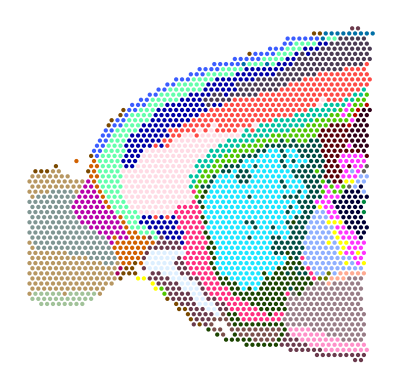

In [5]:
adata1 = multiple_adata[multiple_adata.obs['batch_name'] == 'Mouse_Brain_Anterior']
sc.pl.spatial(adata1, img_key=None, color=['DeepST_domain'], title=[''],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=100)

In [6]:
from pathlib import Path

from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

data_path = Path("../../../data/MBA-MBP") 
df_label = pd.read_csv(data_path / 'Mouse_Brain_Anterior' / 'manual_annotations.tsv', sep='\t',  index_col=0)
#转换index名称
index = [s + '-0' for s in df_label.index]
df_label.index = index
adata1.obs["layer_guess"] = df_label['ground_truth']

In [7]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
ARI = ari_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['leiden'])
print(f"total ARI:{ARI}")

total ARI:0.4125271561118013


In [8]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
NMI = nmi_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['leiden'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['leiden'])
print(f"total AMI:{AMI}")
ACC = 1/2 * (NMI + AMI)
print(f"total ACC:{ACC}")

total NMI:0.6840591534573398
total AMI:0.6538687861871607
total ACC:0.6689639698222503


In [9]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
HOM = hom_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['leiden'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['leiden'])
print(f"total COM:{COM}")
V = 2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total HOM:0.6491944903143217
total COM:0.7228811199325861
total V:0.6840591534573397


D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


[<Axes: xlabel='spatial1', ylabel='spatial2'>]

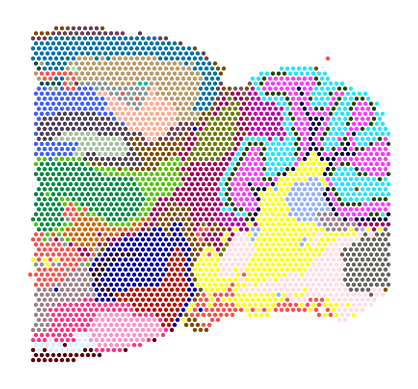

In [10]:
adata2 = multiple_adata[multiple_adata.obs['batch_name'] == 'Mouse_Brain_Posterior']
sc.pl.spatial(adata2, img_key=None, color=['DeepST_domain'], title=[''],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=100)

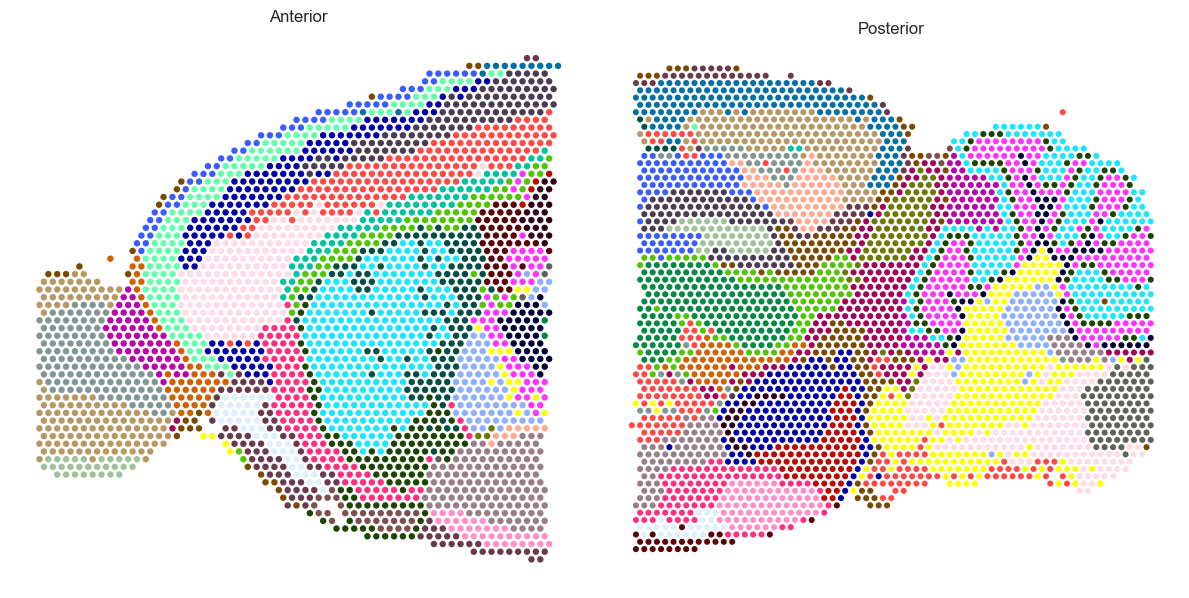

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 绘制第一个批次的空间图
sc.pl.spatial(adata1, ax=axes[0], img_key=None, color=['leiden'], title=['Anterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=100)

# 绘制第二个批次的空间图
sc.pl.spatial(adata2, ax=axes[1], img_key=None, color=['leiden'], title=['Posterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=100)

# 显示图像
plt.tight_layout()
plt.show()

1.0058673117590713


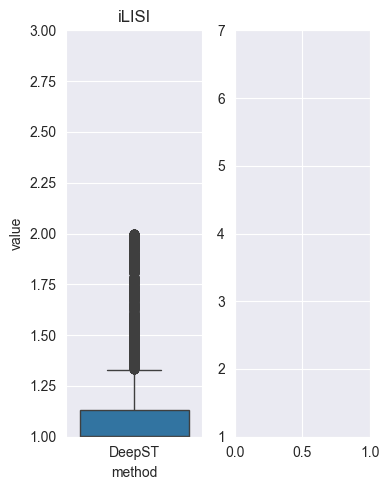

In [12]:
import seaborn as sns
import harmonypy as hm

iLISI = hm.compute_lisi(multiple_adata.obsm['DeepST_embed'], multiple_adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
# cLISI = hm.compute_lisi(multiple_adata.obsm['DeepST_embed'], multiple_adata.obs[['layer_guess']], label_colnames=['layer_guess'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'DeepST',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'DeepST',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
# sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
# axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
# print(np.median(cLISI))